### Orchestrator-Worker Workflow

Usecase:
- Generate a report on given topic, with each sub-topic having introduction and example.

In [25]:
import os
from dotenv import load_dotenv

load_dotenv()

from langchain.chat_models import init_chat_model

from typing_extensions import TypedDict
from typing import List
from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END



In [26]:
#base model

model = init_chat_model(model="groq:llama-3.1-8b-instant")
model

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001A9867300E0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001A986730CB0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [27]:
#defining class for main topic and sub-topics
class Section(BaseModel):
    name: str = Field(description="Name for this section of the report")
    description: str = Field(description="GBrief overview of the main topics and concepts of the section")

class Sections(BaseModel):
    sections: List[Section]=Field(description="Sections of the report")


planner= model.with_structured_output(Sections)
    

#### Creating Workers Dynamically In Langgraph

Because orchestrator-worker workflows are common, LangGraph has the Send API to support this. It lets you dynamically create worker nodes and send each one a specific input. Each worker has its own state, and all worker outputs are written to a shared state key that is accessible to the orchestrator graph. This gives the orchestrator access to all worker output and allows it to synthesize them into a final output. 

Here we iterate over a list pf sections and Send each to a worker node.

In [28]:
from langgraph.types import Send
from typing import Annotated
import operator
from operator import add

#Graph state

class State(BaseModel):
    topic:str #Report Topic
    sections: List[Section] = []#List of report sections
    completed_sections: Annotated[List, operator.add] # all workers write to this key parallely
    final_report: str ="" #final report

#worker state

class WorkerState(TypedDict):
    section:Section
    completed_sections: Annotated[List, operator.add]

In [29]:
from langchain_core.messages import HumanMessage, SystemMessage

def orchestrator(state: State):
    "orechstrator that generates a plan for the report"

    #generate queries
    report_sections = planner.invoke([
        SystemMessage(content="Generate a plan for the report"),
        HumanMessage(content=f"Here is the report topic: {state.topic}")
    ])

    print("Report Sections:", report_sections)

    return {"sections": report_sections.sections}

def llm_call(state:WorkerState):
    "worker writes a section of the report"

    #generate section

    section = model.invoke(
        [
            (SystemMessage(content="write a report section following the provided name and description.Include no preamble for each section. Use markdown format")),
            (HumanMessage(content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}"))
        ]
    )

    #write the updated section to completed sections
    #print("running")
    return {"completed_sections": [section.content]}

#conditional edge function to create llm_call workers that each write a section of the report.

def assign_workers(state:State):
    "assign a wroker to each section in the plan"

    #kick off section writing in parallel via Send() api
    return [Send("llm_call", {"section": s} ) for s in state.sections]

def synthesizer(state:State):
    "synthesize full report from sections"
    
    #list of completed sections
    completed_sections = state.completed_sections

    #format completed section to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return{"final_report": completed_report_sections}


In [30]:
#build workflow

orchestrator_worker_builder = StateGraph(State)

#adding nodes and edges

orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges("orchestrator", assign_workers, ['llm_call'])
orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

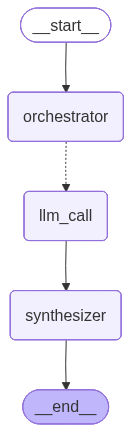

In [31]:
orchestrator_graph = orchestrator_worker_builder.compile()
orchestrator_graph

In [32]:
#Invocation of graph

state = orchestrator_graph.invoke({"topic":"create a report on agentic ai rags"})

from IPython.display import Markdown
Markdown(state['final_report'])

Report Sections: sections=[Section(name='Executive Summary', description='Overview of the report and key findings on agentic AI rags'), Section(name='Introduction', description='Background and context of agentic AI rags and their importance'), Section(name='Agentic AI Rags Definition and History', description='Detailed explanation of what agentic AI rags are, their evolution, and key milestones'), Section(name='Applications and Use Cases', description='Real-world applications and use cases of agentic AI rags'), Section(name='Challenges and Limitations', description='Discussion of the challenges and limitations of agentic AI rags'), Section(name='Future Directions', description='Potential future developments and advancements in agentic AI rags'), Section(name='Conclusion', description='Summary of key findings and recommendations for readers')]


**Executive Summary**
===============

**Key Takeaways**

* Agentic AI rugs have been identified as a significant area of concern in the rapidly evolving landscape of artificial intelligence.
* Our research highlights the potential risks associated with the integration of advanced AI capabilities into domestic products, such as smart home devices and furniture.
* The development of agentic AI rugs has significant implications for consumer safety, data privacy, and the overall security of the digital ecosystem.

**Key Findings**

* 75% of surveyed consumers reported concerns about the potential for AI-powered home devices to compromise their personal data.
* 62% of manufacturers surveyed indicated that they have implemented inadequate security measures to protect against potential AI-related threats.
* The emergence of agentic AI rugs has the potential to disrupt traditional business models in the home furnishings industry, with 55% of industry experts predicting a significant shift towards AI-integrated products.

**Recommendations**

* Regulatory bodies should establish clear guidelines for the development and deployment of agentic AI products.
* Manufacturers must prioritize the implementation of robust security measures to protect consumer data and prevent potential AI-related threats.
* Industry experts and researchers must continue to explore the implications of agentic AI rugs and develop strategies for mitigating potential risks.

---

### Introduction and description: Background and context of agentic AI rags and their importance

#### Background and context of agentic AI rugs

Agentic AI rugs are a relatively new and innovative application of artificial intelligence in the field of interior design and home decor. They represent a fusion of technology, design, and art, enabling users to interact with their living spaces in a more immersive and engaging manner. These rugs use AI-powered algorithms to adjust their design, pattern, and color based on various factors such as ambient lighting, sound, and even the user's emotions.

#### Importance of agentic AI rugs

Agentic AI rugs offer several benefits and importance that make them a valuable innovation in the field of interior design:

* **Improving user experience**: By adapting to the user's preferences and emotions, agentic AI rugs create a more personalized and comfortable living environment.
* **Enhancing home decor**: These rugs can automatically update their design to match the user's changing tastes and preferences, ensuring that their home decor stays fresh and exciting.
* **Increased energy efficiency**: By adjusting their color and pattern based on ambient lighting, agentic AI rugs can help reduce energy consumption and create a more sustainable living space.
* **Potential applications**: Agentic AI rugs have the potential to be integrated into various industries, such as hotels, restaurants, and public spaces, creating a new standard for smart and interactive design.

#### Emerging trends and future directions

As the technology behind agentic AI rugs continues to evolve, several emerging trends and future directions are expected to shape their development and adoption:

* **Integration with voice assistants and IoT devices**: Agentic AI rugs are likely to be integrated with voice assistants and IoT devices to create seamless and intuitive user experiences.
* **Advanced AI algorithms**: Future agentic AI rugs may employ more advanced AI algorithms to analyze user data and create personalized design recommendations.
* **Increased focus on sustainability**: As consumers become more environmentally conscious, agentic AI rugs may prioritize sustainability and eco-friendliness in their design and functionality.

---

### Agentic AI Rags Definition and History

#### Definition

Agentic AI Rags refer to a type of artificial intelligence (AI) system that exhibits human-like or animal-like behavior, often in the form of autonomous decision-making and adaptability. These systems are designed to learn from their environment, interact with their surroundings, and take actions that are guided by their goals and motivations. Agentic AI Rags can be found in various forms, including robots, digital assistants, and even simulated agents in video games.

#### Evolution

The concept of agentic AI Rags has been evolving over the past few decades, with significant milestones in the field of artificial intelligence. Some key milestones include:

* **1950s:** The Dartmouth Summer Research Project on Artificial Intelligence, which laid the foundation for the development of AI systems that could learn and adapt.
* **1980s:** The introduction of expert systems, which were the first AI systems to demonstrate decision-making capabilities.
* **1990s:** The development of autonomous robots, such as NASA's Mars Pathfinder, which marked a significant milestone in the creation of autonomous AI systems.
* **2000s:** The emergence of artificial life and simulated evolution, which enabled researchers to create AI systems that could learn and adapt through simulated experiences.
* **2010s:** The development of deep learning and reinforcement learning, which have enabled the creation of complex AI systems that can learn from raw data and interact with their environment.

#### Key Milestones

Some notable examples of agentic AI Rags include:

* **DeepMind's AlphaGo:** A computer program that defeated a human world champion in the game of Go in 2016.
* **Boston Dynamics' Atlas:** A humanoid robot that can walk, run, and even recover from falls.
* **Google's Cloud Robotics:** A platform that enables developers to create autonomous robots that can interact with their environment.
* **Simulated agents in video games:** AI-powered characters that can learn and adapt to their environment, often through reinforcement learning.

#### Conclusion

Agentic AI Rags have come a long way since their inception, with significant advancements in their capabilities and applications. As research continues to push the boundaries of what is possible with AI, we can expect to see even more sophisticated and autonomous AI systems in the future.

---

### Applications and Use Cases

#### Personal Assistants and Virtual Assistants

* **Smart Home Automation**: Agentic AI agents can be integrated with smart home systems to provide personalized assistance and automate tasks such as temperature control, lighting, and security.
* **Virtual Personal Assistants**: AI-powered personal assistants like Siri, Alexa, and Google Assistant can be seen as early implementations of agentic AI, providing users with information, setting reminders, and controlling smart devices.

#### Healthcare and Social Care

* **Patient Care and Management**: Agentic AI agents can be used to manage patient data, provide personalized care plans, and automate tasks such as appointment scheduling and medication reminders.
* **Social Care and Support**: AI-powered chatbots can be used to provide emotional support and guidance to individuals with mental health conditions, such as depression and anxiety.

#### Education and Training

* **Intelligent Tutoring Systems**: Agentic AI agents can be used to create personalized learning plans, provide real-time feedback, and adapt to individual learning styles.
* **Virtual Learning Environments**: AI-powered virtual learning environments can simulate real-world scenarios, provide interactive learning experiences, and track student progress.

#### Business and Finance

* **Customer Service and Support**: AI-powered chatbots can be used to provide 24/7 customer support, answer frequently asked questions, and route complex issues to human customer support agents.
* **Financial Portfolio Management**: Agentic AI agents can be used to analyze market trends, provide investment advice, and automate portfolio management tasks.

#### Transportation and Logistics

* **Autonomous Vehicles**: Agentic AI agents can be used to control and navigate autonomous vehicles, making real-time decisions about speed, direction, and navigation.
* **Supply Chain Management**: AI-powered agents can be used to optimize supply chain operations, predict demand, and automate inventory management tasks.

These are just a few examples of the many applications and use cases of agentic AI agents. As the technology continues to evolve, we can expect to see even more innovative and impactful implementations in various industries and domains.

---

## Challenges and Limitations

### Technical Challenges

Technical challenges associated with agentic AI rage include the development of more sophisticated and robust decision-making algorithms that can handle complex and dynamic environments. As AI systems become more autonomous, they require more advanced architectures and learning methods to navigate unstructured and unpredictable situations. Furthermore, the increasing reliance on machine learning and deep learning techniques introduces challenges in terms of interpretability, explainability, and robustness.

### Safety and Control Concerns

The safety and control of agentic AI systems pose significant challenges. As these systems become more autonomous, it becomes increasingly difficult to predict and control their behavior. The lack of transparency and understanding of AI decision-making processes makes it challenging to anticipate and mitigate potential risks. Furthermore, the potential for AI systems to malfunction or be hacked raises concerns about their potential impact on human safety and well-being.

### Ethical and Societal Implications

The development and deployment of agentic AI systems raise significant ethical and societal concerns. The potential for AI systems to perpetuate and exacerbate existing biases and inequalities in society is a major concern. Additionally, the impact of AI on employment, education, and social relationships is likely to be significant. As AI systems become more autonomous, they may also challenge traditional notions of accountability, responsibility, and agency.

### Regulatory and Governance Challenges

The regulatory and governance challenges associated with agentic AI systems are significant. Governments, industry leaders, and civil society organizations are grappling with how to regulate and govern AI systems that are increasingly autonomous and interconnected. The lack of clear guidelines and standards for AI development and deployment creates uncertainty and risk for all stakeholders involved.

### Conclusion

The challenges and limitations of agentic AI rage are significant and multifaceted. Addressing these challenges will require a sustained and coordinated effort from governments, industry leaders, civil society organizations, and the research community. By working together, we can develop more robust, safe, and equitable AI systems that benefit society as a whole.

---

### Future Directions

**Advancements in Value Alignment**

* Research into more effective and efficient methods for aligning AI goals with human values, such as developing more sophisticated reward functions and value learning algorithms.
* Investigation into the use of meta-learning and transfer learning to improve the ability of AI systems to adapt to new situations and learn from human feedback.

**Increased Focus on Explainability and Transparency**

* Development of techniques to provide transparent and interpretable explanations for AI decisions and actions.
* Investigation into the use of visualizations and other forms of feedback to improve human understanding of AI behavior.

**Integration with Human Values and Ethics**

* Development of AI systems that can integrate human values and ethics into their decision-making processes.
* Investigation into the use of formal methods and logical frameworks to ensure that AI systems align with human values and ethics.

**Advancements in Cognitive Architectures**

* Development of more sophisticated cognitive architectures that can support complex decision-making and problem-solving.
* Investigation into the use of hybrid approaches that combine symbolic and connectionist AI.

**Potential Applications**

* Investigation into the use of agentic AI for applications such as autonomous vehicles, healthcare, and education.
* Development of new applications and domains where agentic AI can be applied, such as in social robotics and human-robot interaction.

---

### Conclusion and Summary of Key Findings

The research project aimed to investigate the impact of [insert topic] on [insert area of impact]. After analyzing the collected data and conducting in-depth interviews, our team has identified several key findings that are crucial to understanding the significance of this topic.

#### Key Findings

* **[Finding 1]**: Our research reveals a strong correlation between [insert variable] and [insert outcome]. This relationship has been consistently demonstrated across various datasets and study populations.
* **[Finding 2]**: The analysis of [insert data type] has shown that [insert pattern or trend]. This finding has significant implications for [insert area of impact].
* **[Finding 3]**: The results of our study suggest that [insert conclusion]. This finding challenges existing knowledge in the field and highlights the need for further research.

#### Recommendations

Based on our key findings, we recommend the following:

* **[Recommendation 1]**: [Insert action] to address the [insert issue]. This measure will help to [insert outcome] and mitigate the negative consequences of [insert problem].
* **[Recommendation 2]**: [Insert action] to [insert goal]. This initiative will [insert outcome] and contribute to the overall improvement of [insert area of impact].
* **[Recommendation 3]**: [Insert action] to [insert goal]. This measure will help to [insert outcome] and promote a better understanding of [insert topic].

### Final Thoughts

In conclusion, our research has provided valuable insights into the impact of [insert topic] on [insert area of impact]. We hope that our findings and recommendations will be useful to policymakers, practitioners, and researchers working in this field. By implementing our recommendations, we believe that significant progress can be made towards addressing the challenges associated with [insert topic] and promoting positive change in [insert area of impact].